# AI Agent, dịch chuyển kỹ năng và rủi ro chất lượng code trong ngành Khoa học máy tính

**Câu chuyện phân tích:** trước khi có AI, công việc lập trình xoay quanh việc con người trực tiếp viết code, debug, test và viết tài liệu. Khi AI tham gia workflow, số lượng code và bản nháp kỹ thuật có thể tăng nhanh. Nhưng output nhanh hơn không tự đồng nghĩa với chất lượng tốt hơn. Câu hỏi hữu ích hơn là:

> AI có đang dịch chuyển điểm nghẽn từ viết code sang review, test, bảo trì và quản trị chất lượng code không?

Notebook này phân tích câu hỏi đó bằng dữ liệu cấp task hiện có. Notebook không khẳng định nhân quả rằng AI làm giảm chất lượng code, vì dữ liệu không có metric trực tiếp như defect rate, failed CI, bug report hay production incident. Thay vào đó, phân tích dùng các proxy để nhận diện nơi AI có thể tăng tốc output và nơi con người vẫn phải kiểm soát chất lượng.

Đầu ra của notebook:

- `outputs/cs_agent_task_recommendations.csv`
- `outputs/cs_task_group_summary.csv`
- `outputs/cs_occupation_agent_summary.csv`
- `outputs/figures/*.png`

In [26]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

ROOT = Path('..') if Path.cwd().name == 'outputs' else Path('.')
OUT = ROOT / 'outputs'
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 120)

PALETTE = {
    'ink': '#12212B', 'muted': '#6B7280', 'paper': '#FBFAF7', 'grid': '#E7ECEF',
    'teal': '#0A9396', 'mint': '#94D2BD', 'coral': '#EE6C4D', 'gold': '#E9C46A',
    'navy': '#15324A', 'purple': '#7B2CBF', 'green': '#2A9D8F', 'red': '#D1495B'
}

sns.set_theme(style='whitegrid', context='talk', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor': PALETTE['paper'], 'axes.facecolor': PALETTE['paper'],
    'axes.edgecolor': PALETTE['ink'], 'axes.labelcolor': PALETTE['ink'],
    'text.color': PALETTE['ink'], 'xtick.color': PALETTE['ink'], 'ytick.color': PALETTE['ink'],
    'grid.color': PALETTE['grid'], 'grid.linewidth': 1.0,
    'axes.titleweight': 'bold', 'axes.titlepad': 14,
    'savefig.facecolor': PALETTE['paper'], 'savefig.bbox': 'tight', 'savefig.dpi': 220,
})

def savefig(fig, name):
    path = FIG / name
    fig.savefig(path, dpi=220, bbox_inches='tight', facecolor=fig.get_facecolor())
    return path

def clean_axis(ax, xgrid=False):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_alpha(.25)
    ax.spines['bottom'].set_alpha(.25)
    ax.grid(True, axis='x' if xgrid else 'y', alpha=.65)
    ax.grid(False, axis='y' if xgrid else 'x')
    return ax

def title(ax, main, sub=None):
    ax.set_title(main, loc='left', fontsize=18, fontweight='bold', color=PALETTE['ink'])
    if sub:
        ax.text(0, 1.03, sub, transform=ax.transAxes, fontsize=11.5, color=PALETTE['muted'], va='bottom')

## 1. Đọc dữ liệu và xác định phạm vi Khoa học máy tính

In [27]:
task = pd.read_csv(ROOT / 'outputs' / 'task_ai_skill_shift.csv')
skill = pd.read_csv(ROOT / 'outputs' / 'skill_shift_summary.csv')
occ = pd.read_csv(ROOT / 'outputs' / 'occupation_shift_summary.csv')
sector = pd.read_csv(ROOT / 'outputs' / 'sector_shift_summary.csv')
worker_group = pd.read_csv(ROOT / 'outputs' / 'worker_group_summary.csv')

cs = task[task['sector'].eq('Computer and Mathematical')].copy()

summary = pd.DataFrame({
    'metric': ['All task', 'CS task', 'CS occupations', 'Worker signal in CS', 'Expert signal in CS', 'Paired worker-expert in CS'],
    'value': [
        len(task), len(cs), cs['Occupation (O*NET-SOC Title)'].nunique(),
        int(cs['has_worker_signal'].sum()), int(cs['has_expert_signal'].sum()),
        int(cs['paired_worker_expert_signal'].sum())
    ]
})
summary

,metric,value
0,All task,2131
1,CS task,261
2,CS occupations,29
3,Worker signal in CS,173
4,Expert signal in CS,173
5,Paired worker-expert in CS,173


In [28]:
sector_cs = sector[sector['sector'].eq('Computer and Mathematical')].iloc[0]
print('Computer and Mathematical sector snapshot')
for c in ['task_count','occupation_count','automation_exposure_index','worker_pull_index','human_complementarity_index','innovation_momentum_index','skill_shift_pressure']:
    val = sector_cs[c]
    if isinstance(val, (float, np.floating)):
        print(f'{c:32s}: {val:.3f}')
    else:
        print(f'{c:32s}: {val}')

Computer and Mathematical sector snapshot
task_count                      : 261
occupation_count                : 29
automation_exposure_index       : 0.699
worker_pull_index               : 0.514
human_complementarity_index     : 0.509
innovation_momentum_index       : 0.790
skill_shift_pressure            : 1.191


**Insight 1.** Ngành `Computer and Mathematical` rất phù hợp để phân tích AI Agent: mức tiếp xúc với AI và động lực đổi mới đều cao, nhưng vai trò bổ trợ của con người vẫn rõ. Điều này ủng hộ câu chuyện dịch chuyển kỹ năng, không phải câu chuyện thay thế đơn giản.

## 2. Tạo nhóm task và hai chỉ số phân tích

In [29]:
patterns = {
    'Code generation / development': r'code|coding|program|software|application|web|develop|debug|script|database|algorithm',
    'Quality control / QA / review': r'test|quality|qa|defect|bug|debug|review|validate|verification|security|vulnerab|audit|monitor|troubleshoot|compatibility',
    'Architecture / governance': r'architect|design|requirement|specification|system|model|plan|integration|technical guidance|evaluate technology|security|policy',
    'Documentation / reporting': r'document|report|record|manual|procedure|standard|summary'
}

# Keep all Vietnamese labels generated from unicode escapes so the notebook is robust on Windows terminals.
def U(s):
    return s.encode('ascii').decode('unicode_escape')

def classify_task(row):
    text = f"{row.get('Task','')} {row.get('Occupation (O*NET-SOC Title)','')}".lower()
    if re.search(patterns['Quality control / QA / review'], text, flags=re.I):
        return 'Quality control / QA / review'
    if re.search(patterns['Code generation / development'], text, flags=re.I):
        return 'Code generation / development'
    if re.search(patterns['Architecture / governance'], text, flags=re.I):
        return 'Architecture / governance'
    if re.search(patterns['Documentation / reporting'], text, flags=re.I):
        return 'Documentation / reporting'
    return 'Other CS tasks'

cs['task_group'] = cs.apply(classify_task, axis=1)

# Conservative quality-critical flag: these tasks should not be fully autonomous even when exposure is high.
quality_critical_pattern = (
    r'test|quality|qa|defect|bug|debug|review|validate|verification|security|vulnerab|audit|'
    r'troubleshoot|compatibility|production|disaster recovery|backup|technical guidance|compliance'
)
cs['quality_critical_task'] = (
    cs['Task'].str.contains(quality_critical_pattern, case=False, na=False, regex=True)
    | cs['Occupation (O*NET-SOC Title)'].str.contains(r'security|quality assurance|systems|administrator', case=False, na=False, regex=True)
)

def norm01(s):
    s = pd.to_numeric(s, errors='coerce')
    if s.notna().sum() == 0 or np.isclose(s.max(), s.min()):
        return pd.Series(np.nan, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

cs['uncertainty_norm'] = norm01(cs['expert_uncertainty_requirement'])
cs['domain_expertise_norm'] = norm01(cs['expert_domain_expertise_requirement'])
cs['interpersonal_norm'] = norm01(cs['expert_interpersonal_requirement'])

accel_cols = ['automation_exposure_index', 'innovation_momentum_index', 'worker_pull_index']
risk_cols = ['human_complementarity_index', 'uncertainty_norm', 'domain_expertise_norm', 'human_agency_quality_oversight_share']
cs['code_acceleration_potential'] = cs[accel_cols].mean(axis=1, skipna=True)
cs['quality_risk_need'] = cs[risk_cols].mean(axis=1, skipna=True)

accel_hi = cs['code_acceleration_potential'].quantile(.67)
risk_hi = cs['quality_risk_need'].quantile(.67)
accel_lo = cs['code_acceleration_potential'].quantile(.33)
risk_lo = cs['quality_risk_need'].quantile(.33)

recommendation_order = [
    U('Agent b\\u00e1n t\\u1ef1 \\u0111\\u1ed9ng'),
    U('Copilot + review b\\u1eaft bu\\u1ed9c'),
    U('Con ng\\u01b0\\u1eddi d\\u1eabn d\\u1eaft, AI h\\u1ed7 tr\\u1ee3'),
    U('Th\\u1eed nghi\\u1ec7m / theo d\\u00f5i'),
    U('C\\u1ea7n th\\u00eam d\\u1eef li\\u1ec7u'),
]

def recommend(row):
    a, r = row['code_acceleration_potential'], row['quality_risk_need']
    if pd.isna(a) or pd.isna(r):
        return recommendation_order[4]
    # Conservative override: high-acceleration quality-critical tasks require review.
    if row['quality_critical_task'] and a >= accel_hi:
        return recommendation_order[1]
    if a >= accel_hi and r < risk_lo:
        return recommendation_order[0]
    if a >= accel_hi and r >= risk_lo:
        return recommendation_order[1]
    if a < accel_hi and r >= risk_hi:
        return recommendation_order[2]
    return recommendation_order[3]

cs['agent_recommendation'] = cs.apply(recommend, axis=1)

group_order = ['Code generation / development', 'Quality control / QA / review', 'Architecture / governance', 'Documentation / reporting', 'Other CS tasks']
group_labels = {
    'Code generation / development': U('Sinh code / ph\\u00e1t tri\\u1ec3n'),
    'Quality control / QA / review': U('Ki\\u1ec3m th\\u1eed / QA / review'),
    'Architecture / governance': U('Ki\\u1ebfn tr\\u00fac / qu\\u1ea3n tr\\u1ecb'),
    'Documentation / reporting': U('T\\u00e0i li\\u1ec7u / b\\u00e1o c\\u00e1o'),
    'Other CS tasks': U('Task CS kh\\u00e1c'),
}
group_order_vi = [group_labels[x] for x in group_order]
cs['task_group_vi'] = cs['task_group'].map(group_labels)

cs['task_group_vi'].value_counts().reindex(group_order_vi)

task_group_vi
Sinh code / phát triển    83
Kiểm thử / QA / review    88
Kiến trúc / quản trị      52
Tài liệu / báo cáo        16
Task CS khác              22
Name: count, dtype: int64

Notebook dùng hai chỉ số tự tạo:

- `code_acceleration_potential`: mức AI có thể tăng tốc tạo output code/kỹ thuật.
- `quality_risk_need`: mức task vẫn cần kiểm soát chất lượng, chuyên môn và phán đoán con người.

Ngoài ra notebook thêm cờ `quality_critical_task` cho các task test, QA, security, troubleshooting, backup, disaster recovery, production/compliance. Các task này được áp rule bảo thủ: nếu AI có tiềm năng tăng tốc cao thì khuyến nghị tối thiểu phải là `Copilot + review bắt buộc`, không gán thẳng cho agent tự động.

## 3. Biểu đồ 1 - Tăng tốc output và rủi ro chất lượng theo nhóm task

,task_group_vi,task_count,automation_exposure_index,innovation_momentum_index,human_complementarity_index,quality_risk_need,skill_shift_pressure
0,Sinh code / phát triển,83,0.731,0.842,0.471,0.394,1.408
1,Kiểm thử / QA / review,88,0.729,0.821,0.539,0.448,1.100
2,Kiến trúc / quản trị,52,0.638,0.698,0.517,0.428,0.602
3,Tài liệu / báo cáo,16,0.684,0.711,0.439,0.395,2.421
4,Task CS khác,22,0.619,0.740,0.536,0.488,1.217


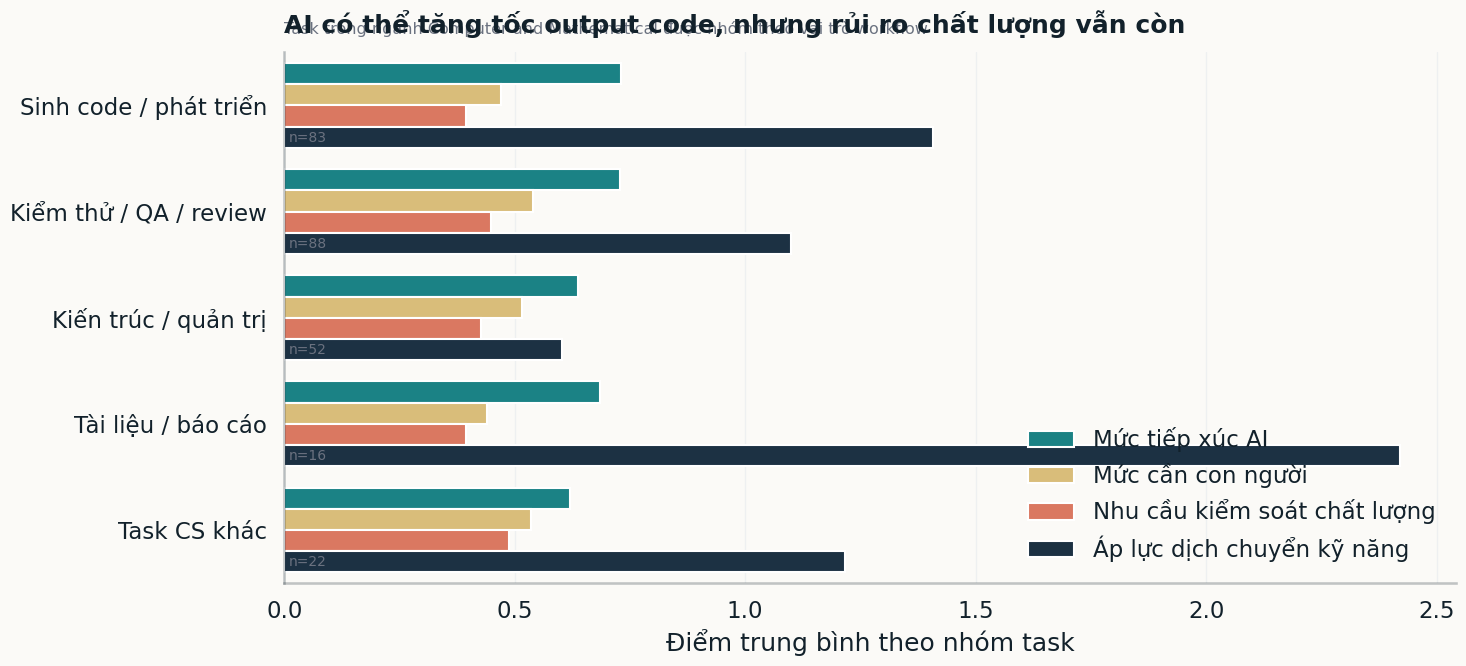

In [30]:
group_summary = (cs.groupby('task_group_vi')
    .agg(task_count=('Task ID','count'),
         automation_exposure_index=('automation_exposure_index','mean'),
         innovation_momentum_index=('innovation_momentum_index','mean'),
         human_complementarity_index=('human_complementarity_index','mean'),
         quality_risk_need=('quality_risk_need','mean'),
         skill_shift_pressure=('skill_shift_pressure','mean'))
    .reindex(group_order_vi)
    .dropna(how='all')
    .reset_index())

display(group_summary.round(3))

plot_df = group_summary.melt(
    id_vars=['task_group_vi','task_count'],
    value_vars=['automation_exposure_index','human_complementarity_index','quality_risk_need','skill_shift_pressure'],
    var_name='metric', value_name='score'
)
metric_labels = {
    'automation_exposure_index': 'Mức tiếp xúc AI',
    'human_complementarity_index': 'Mức cần con người',
    'quality_risk_need': 'Nhu cầu kiểm soát chất lượng',
    'skill_shift_pressure': 'Áp lực dịch chuyển kỹ năng'
}
plot_df['metric_label'] = plot_df['metric'].map(metric_labels)

fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(
    data=plot_df, y='task_group_vi', x='score', hue='metric_label',
    palette=[PALETTE['teal'], PALETTE['gold'], PALETTE['coral'], PALETTE['navy']], ax=ax
)
title(ax, 'AI có thể tăng tốc output code, nhưng rủi ro chất lượng vẫn còn',
      'Task trong ngành Computer and Mathematical được nhóm theo vai trò workflow')
ax.set_xlabel('Điểm trung bình theo nhóm task')
ax.set_ylabel('')
ax.legend(title='', frameon=False, loc='lower right')
clean_axis(ax, xgrid=True)
for i, row in group_summary.iterrows():
    ax.text(0.01, i + 0.34, f"n={int(row['task_count'])}", color=PALETTE['muted'], fontsize=10)
plt.tight_layout()
savefig(fig, '01_group_signal_comparison.png')
plt.show()

**Insight 2.** Nhóm task code/development có Mức tiếp xúc AI và innovation momentum cao. Nhóm QA/review/test cũng có exposure cao, nhưng vẫn giữ tín hiệu rủi ro chất lượng và human complementarity đáng kể. Điểm nghẽn đang dịch từ viết code sang kiểm định code.

## 4. Biểu đồ 2 - Quadrant khuyến nghị AI Agent

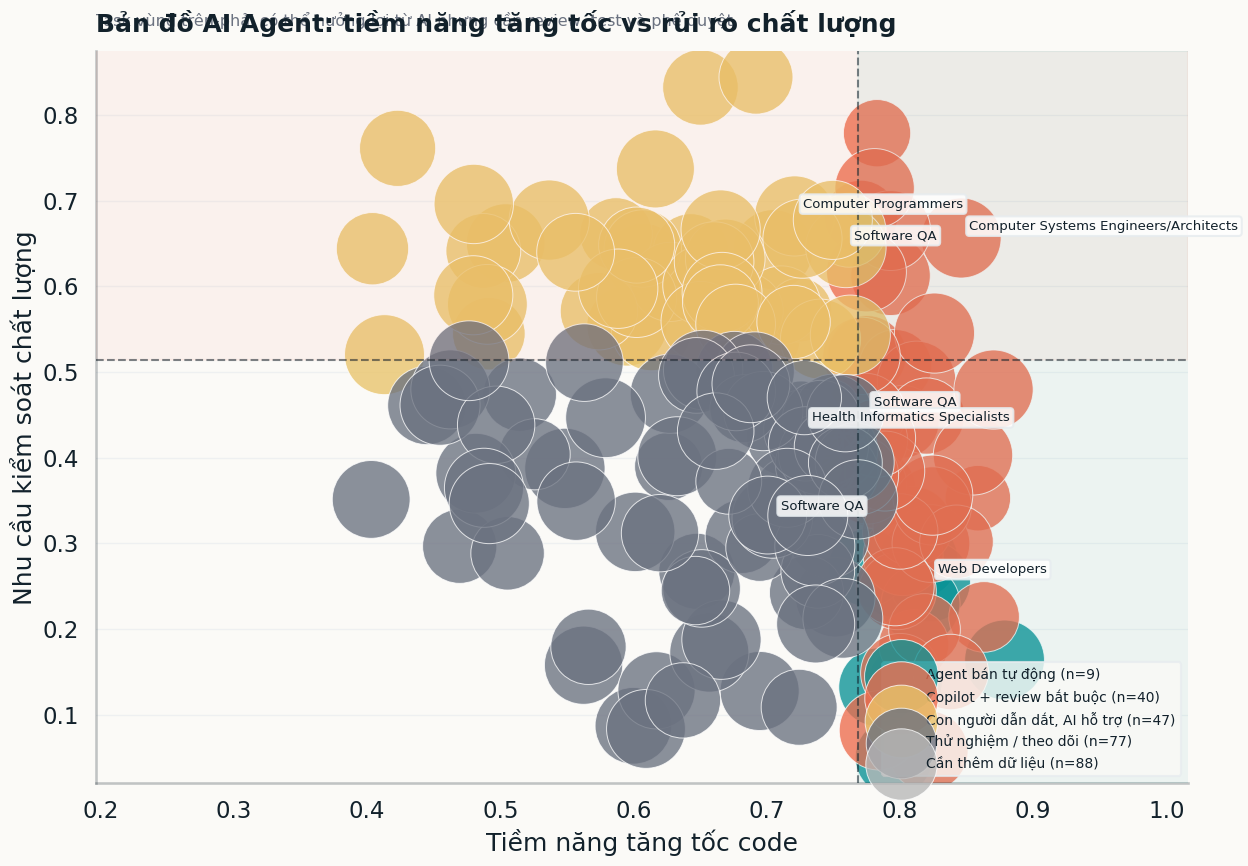

In [31]:
rec_colors = {
    'Agent bán tự động': PALETTE['teal'],
    'Copilot + review bắt buộc': PALETTE['coral'],
    'Con người dẫn dắt, AI hỗ trợ': PALETTE['gold'],
    'Thử nghiệm / theo dõi': PALETTE['muted'],
    'Cần thêm dữ liệu': '#B8B8B8'
}

fig, ax = plt.subplots(figsize=(13, 9))
for rec in recommendation_order:
    sub = cs[cs['agent_recommendation'].eq(rec)]
    if sub.empty:
        continue
    ax.scatter(
        sub['code_acceleration_potential'], sub['quality_risk_need'],
        s=45 + 90*sub['task_importance_weight'].fillna(sub['task_importance_weight'].median()),
        alpha=.78, color=rec_colors[rec], edgecolor='white', linewidth=.7, label=f'{rec} (n={len(sub)})'
    )

ax.axvline(accel_hi, color=PALETTE['ink'], lw=1.5, ls='--', alpha=.55)
ax.axhline(risk_hi, color=PALETTE['ink'], lw=1.5, ls='--', alpha=.55)
ax.axvspan(accel_hi, 1.02, color=PALETTE['teal'], alpha=.06)
ax.axhspan(risk_hi, 1.02, color=PALETTE['coral'], alpha=.06)

title(ax, 'Bản đồ AI Agent: tiềm năng tăng tốc vs rủi ro chất lượng',
      'Task vùng trên-phải có thể hưởng lợi từ AI nhưng cần review, test và phê duyệt')
ax.set_xlabel('Tiềm năng tăng tốc code')
ax.set_ylabel('Nhu cầu kiểm soát chất lượng')
ax.set_xlim(max(0, cs['code_acceleration_potential'].min()-0.03), min(1.02, cs['code_acceleration_potential'].max()+0.03))
ax.set_ylim(max(0, cs['quality_risk_need'].min()-0.03), min(1.02, cs['quality_risk_need'].max()+0.03))
ax.legend(frameon=True, facecolor=PALETTE['paper'], edgecolor=PALETTE['grid'], fontsize=10, loc='lower right')
clean_axis(ax)

ann = cs.dropna(subset=['code_acceleration_potential','quality_risk_need']).copy()
ann['label_score'] = ann['code_acceleration_potential'] + ann['quality_risk_need'] + ann['task_importance_weight'].fillna(0)
for _, row in ann.sort_values('label_score', ascending=False).head(7).iterrows():
    label = row['Occupation (O*NET-SOC Title)'].replace('Software Quality Assurance Analysts and Testers','Software QA')
    ax.annotate(label, (row['code_acceleration_potential'], row['quality_risk_need']),
        xytext=(6, 6), textcoords='offset points', fontsize=9.5, color=PALETTE['ink'],
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=PALETTE['grid'], alpha=.86))

plt.tight_layout()
savefig(fig, '02_agent_quadrant.png')
plt.show()

**Insight 3.** Vùng trên-phải là vùng chiến lược: AI có thể tăng tốc output, nhưng rủi ro chất lượng cũng cao. Các task này không nên giao cho agent tự động hoàn toàn; phù hợp hơn với `Copilot + review bắt buộc`.

## 5. Biểu đồ 3 - Khoảng cách giữa tăng tốc output và rủi ro chất lượng theo nghề

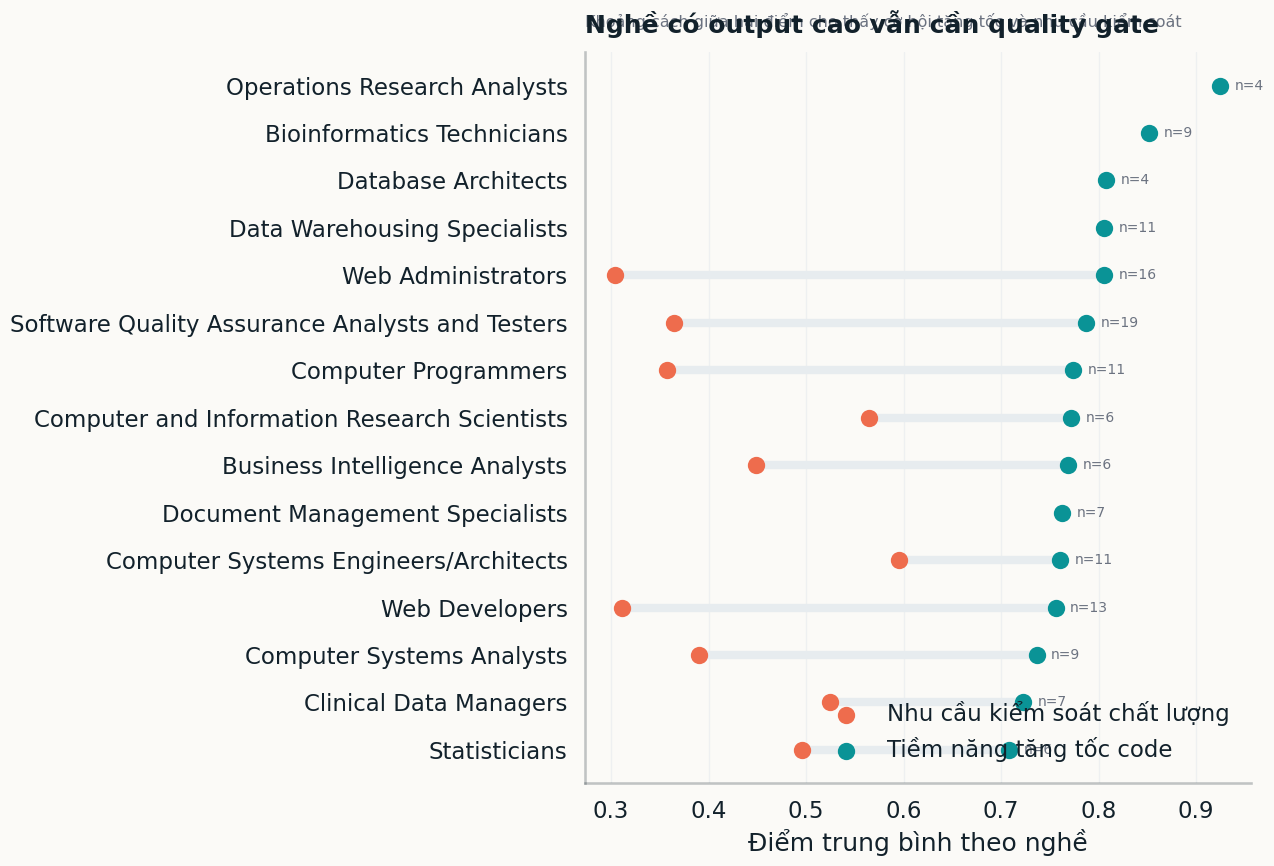

In [32]:
occ_cs = (cs.groupby('Occupation (O*NET-SOC Title)')
    .agg(task_count=('Task ID','count'),
         code_acceleration_potential=('code_acceleration_potential','mean'),
         quality_risk_need=('quality_risk_need','mean'),
         automation_exposure_index=('automation_exposure_index','mean'),
         human_complementarity_index=('human_complementarity_index','mean'),
         skill_shift_pressure=('skill_shift_pressure','mean'))
    .reset_index())
occ_cs = occ_cs[occ_cs['task_count'] >= 4].sort_values('code_acceleration_potential', ascending=False)
top_occ = occ_cs.head(15).copy().sort_values('code_acceleration_potential')

fig, ax = plt.subplots(figsize=(13, 9))
y = np.arange(len(top_occ))
ax.hlines(y, top_occ['quality_risk_need'], top_occ['code_acceleration_potential'], color=PALETTE['grid'], lw=6, zorder=1)
ax.scatter(top_occ['quality_risk_need'], y, s=120, color=PALETTE['coral'], label='Nhu cầu kiểm soát chất lượng', zorder=2)
ax.scatter(top_occ['code_acceleration_potential'], y, s=120, color=PALETTE['teal'], label='Tiềm năng tăng tốc code', zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(top_occ['Occupation (O*NET-SOC Title)'])
ax.set_xlabel('Điểm trung bình theo nghề')
ax.set_ylabel('')
title(ax, 'Nghề có output cao vẫn cần quality gate',
      'Khoảng cách giữa hai điểm cho thấy cơ hội tăng tốc và nhu cầu kiểm soát')
ax.legend(frameon=False, loc='lower right')
clean_axis(ax, xgrid=True)
for i, row in enumerate(top_occ.itertuples()):
    ax.text(max(row.code_acceleration_potential, row.quality_risk_need)+0.015, i, f"n={row.task_count}", va='center', fontsize=10, color=PALETTE['muted'])
plt.tight_layout()
savefig(fig, '03_occupation_dumbbell.png')
plt.show()

**Insight 4.** Web Developers, Computer Programmers, Software QA Analysts/Testers và Computer Systems Analysts là các nhóm nên ưu tiên triển khai AI. Tuy nhiên khuyến nghị phải phân tầng: task sinh code có thể tăng tốc, còn review, test, security và task ảnh hưởng production cần quality gate mạnh hơn.

## 6. Biểu đồ 4 - Cấu trúc transition type theo nhóm task

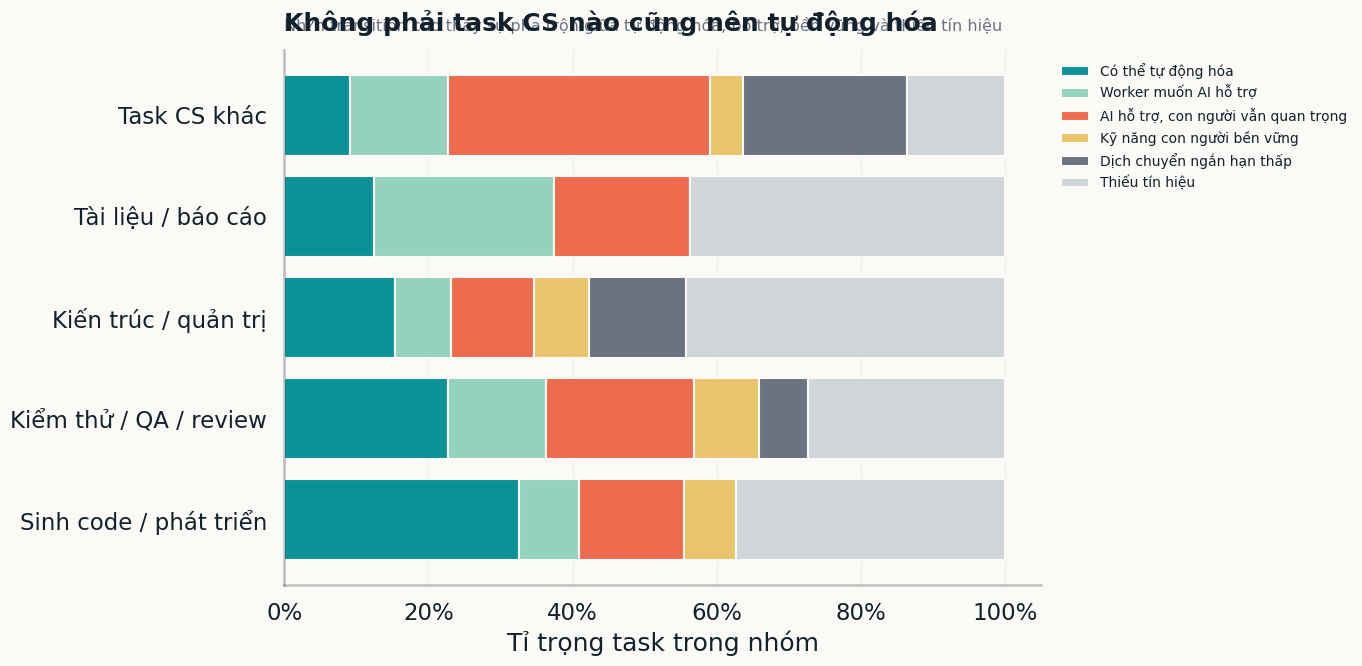

In [33]:
transition_labels = {
    'Automation candidate': U('C\\u00f3 th\\u1ec3 t\\u1ef1 \\u0111\\u1ed9ng h\\u00f3a'),
    'Worker-pulled automation': U('Worker mu\\u1ed1n AI h\\u1ed7 tr\\u1ee3'),
    'AI-augmented human premium': U('AI h\\u1ed7 tr\\u1ee3, con ng\\u01b0\\u1eddi v\\u1eabn quan tr\\u1ecdng'),
    'Durable human skill': U('K\\u1ef9 n\\u0103ng con ng\\u01b0\\u1eddi b\\u1ec1n v\\u1eefng'),
    'Low near-term shift': U('D\\u1ecbch chuy\\u1ec3n ng\\u1eafn h\\u1ea1n th\\u1ea5p'),
    'Insufficient signal': U('Thi\\u1ebfu t\\u00edn hi\\u1ec7u')
}
cs['transition_type_vi'] = cs['transition_type'].map(transition_labels).fillna(cs['transition_type'])
trans = (cs.groupby(['task_group_vi','transition_type_vi']).size().reset_index(name='count'))
trans['share'] = trans.groupby('task_group_vi')['count'].transform(lambda x: x / x.sum())
trans_pivot = trans.pivot(index='task_group_vi', columns='transition_type_vi', values='share').fillna(0).reindex(group_order_vi).dropna(how='all')
transition_order = list(transition_labels.values())
transition_colors = {
    transition_labels['Automation candidate']: PALETTE['teal'],
    transition_labels['Worker-pulled automation']: PALETTE['mint'],
    transition_labels['AI-augmented human premium']: PALETTE['coral'],
    transition_labels['Durable human skill']: PALETTE['gold'],
    transition_labels['Low near-term shift']: PALETTE['muted'],
    transition_labels['Insufficient signal']: '#D0D5DA'
}

fig, ax = plt.subplots(figsize=(14, 7))
left = np.zeros(len(trans_pivot))
for col in transition_order:
    if col not in trans_pivot.columns:
        continue
    vals = trans_pivot[col].values
    ax.barh(trans_pivot.index, vals, left=left, color=transition_colors[col], label=col, edgecolor=PALETTE['paper'])
    left += vals
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.set_xlabel(U('T\\u1ec9 tr\\u1ecdng task trong nh\\u00f3m'))
ax.set_ylabel('')
title(ax, U('Kh\\u00f4ng ph\\u1ea3i task CS n\\u00e0o c\\u0169ng n\\u00ean t\\u1ef1 \\u0111\\u1ed9ng h\\u00f3a'),
      U('Nh?n transition cho th\\u1ea5y s\\u1ef1 pha tr\\u1ed9n gi\\u1eefa t\\u1ef1 \\u0111\\u1ed9ng h\\u00f3a, b\\u1ed5 tr\\u1ee3, b\\u1ec1n v\\u1eefng v\\u00e0 thi\\u1ebfu t\\u00edn hi\\u1ec7u'))
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
clean_axis(ax, xgrid=True)
plt.tight_layout()
savefig(fig, '04_transition_composition.png')
plt.show()

**Insight 5.** Dữ liệu ủng hộ chiến lược AI Agent phân tầng. Một số task là automation candidate, nhưng nhiều task thuộc nhóm `AI-augmented human premium`, nghĩa là AI hỗ trợ được nhưng phán đoán con người vẫn là trung tâm.

## 7. Biểu đồ 5 - PCA bản đồ tín hiệu dịch chuyển kỹ năng

,PC1,PC2
automation_exposure_index,-0.389,0.535
worker_pull_index,-0.163,0.071
human_complementarity_index,0.518,0.259
innovation_momentum_index,-0.125,0.761
expert_uncertainty_requirement,0.465,0.178
expert_domain_expertise_requirement,0.442,0.141
human_agency_quality_oversight_share,0.355,0.099


Explained variance: [0.422, 0.214]
PCA task count: 173


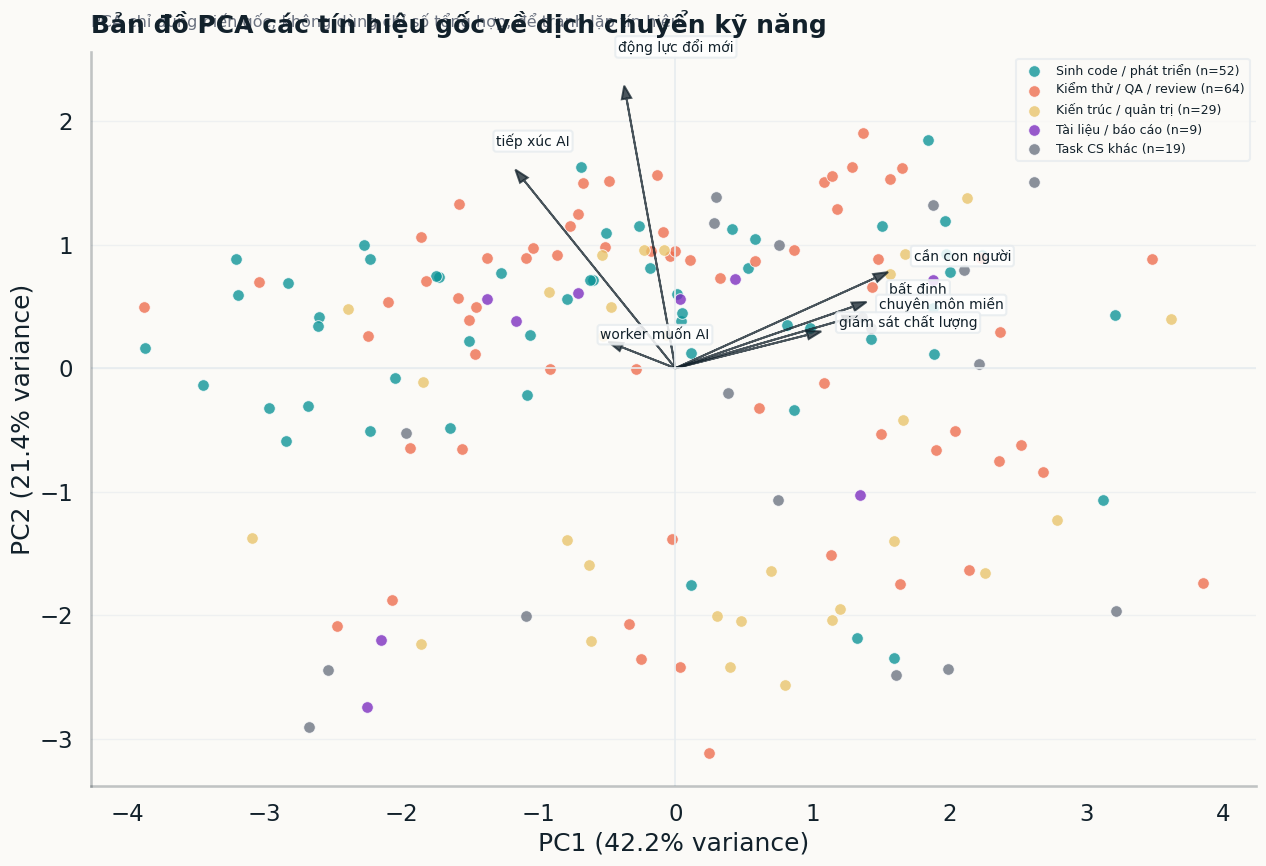

In [34]:
# PCA uses only base signals, not composite indices, to avoid circular structure.
pca_features = [
    'automation_exposure_index',
    'worker_pull_index',
    'human_complementarity_index',
    'innovation_momentum_index',
    'expert_uncertainty_requirement',
    'expert_domain_expertise_requirement',
    'human_agency_quality_oversight_share'
]
pca_df = cs.dropna(subset=pca_features).copy()
X = pca_df[pca_features].copy()
Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xs)
pca_df['PC1'] = coords[:,0]
pca_df['PC2'] = coords[:,1]
pca_df['task_group_vi'] = pca_df['task_group'].map(group_labels)
loadings = pd.DataFrame(pca.components_.T, index=pca_features, columns=['PC1','PC2'])
explained = pca.explained_variance_ratio_

display(loadings.round(3))
print('Explained variance:', [round(x, 3) for x in explained])
print('PCA task count:', len(pca_df))

group_palette = {
    group_labels['Code generation / development']: PALETTE['teal'],
    group_labels['Quality control / QA / review']: PALETTE['coral'],
    group_labels['Architecture / governance']: PALETTE['gold'],
    group_labels['Documentation / reporting']: PALETTE['purple'],
    group_labels['Other CS tasks']: PALETTE['muted']
}

fig, ax = plt.subplots(figsize=(13, 9))
for grp in group_order_vi:
    sub = pca_df[pca_df['task_group_vi'].eq(grp)]
    if sub.empty:
        continue
    ax.scatter(sub['PC1'], sub['PC2'], s=70, alpha=.78, color=group_palette[grp], edgecolor='white', linewidth=.7, label=f'{grp} (n={len(sub)})')

loading_labels = {
    'automation_exposure_index': U('ti\\u1ebfp x\\u00fac AI'),
    'worker_pull_index': U('worker mu\\u1ed1n AI'),
    'human_complementarity_index': U('c\\u1ea7n con ng\\u01b0\\u1eddi'),
    'innovation_momentum_index': U('\\u0111\\u1ed9ng l\\u1ef1c \\u0111\\u1ed5i m\\u1edbi'),
    'expert_uncertainty_requirement': U('b\\u1ea5t \\u0111\\u1ecbnh'),
    'expert_domain_expertise_requirement': U('chuy\\u00ean m\\u00f4n mi\\u1ec1n'),
    'human_agency_quality_oversight_share': U('gi\\u00e1m s\\u00e1t ch\\u1ea5t l\\u01b0\\u1ee3ng'),
}
arrow_scale = 3.0
for feat, row in loadings.iterrows():
    ax.arrow(0, 0, row['PC1']*arrow_scale, row['PC2']*arrow_scale, color=PALETTE['ink'], alpha=.75,
             head_width=.07, length_includes_head=True, linewidth=1.4)
    ax.text(row['PC1']*arrow_scale*1.12, row['PC2']*arrow_scale*1.12, loading_labels[feat], fontsize=10, color=PALETTE['ink'],
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=PALETTE['grid'], alpha=.85))

ax.axhline(0, color=PALETTE['grid'], lw=1.2)
ax.axvline(0, color=PALETTE['grid'], lw=1.2)
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
title(ax, U('B\\u1ea3n \\u0111\\u1ed3 PCA c\\u00e1c t\\u00edn hi\\u1ec7u g\\u1ed1c v\\u1ec1 d\\u1ecbch chuy\\u1ec3n k\\u1ef9 n\\u0103ng'),
      U('PCA ch\\u1ec9 d\\u00f9ng bi\\u1ebfn g\\u1ed1c, kh\\u00f4ng d\\u00f9ng ch\\u1ec9 s\\u1ed1 t\\u1ed5ng h\\u1ee3p, \\u0111\\u1ec3 tr\\u00e1nh l\\u1eb7p t\\u00edn hi\\u1ec7u'))
ax.legend(frameon=True, facecolor=PALETTE['paper'], edgecolor=PALETTE['grid'], fontsize=9, loc='best')
clean_axis(ax)
plt.tight_layout()
savefig(fig, '05_pca_skill_shift_map.png')
plt.show()

**Insight 6.** PCA cho cái nhìn gọn về cấu trúc dịch chuyển kỹ năng. Điểm quan trọng là AI acceleration và human quality oversight không phải cùng một chiều. Vì vậy mô hình khuyến nghị cần kết hợp cả tiềm năng năng suất và rủi ro chất lượng.

## 8. Biểu đồ 6 - Heatmap tương quan

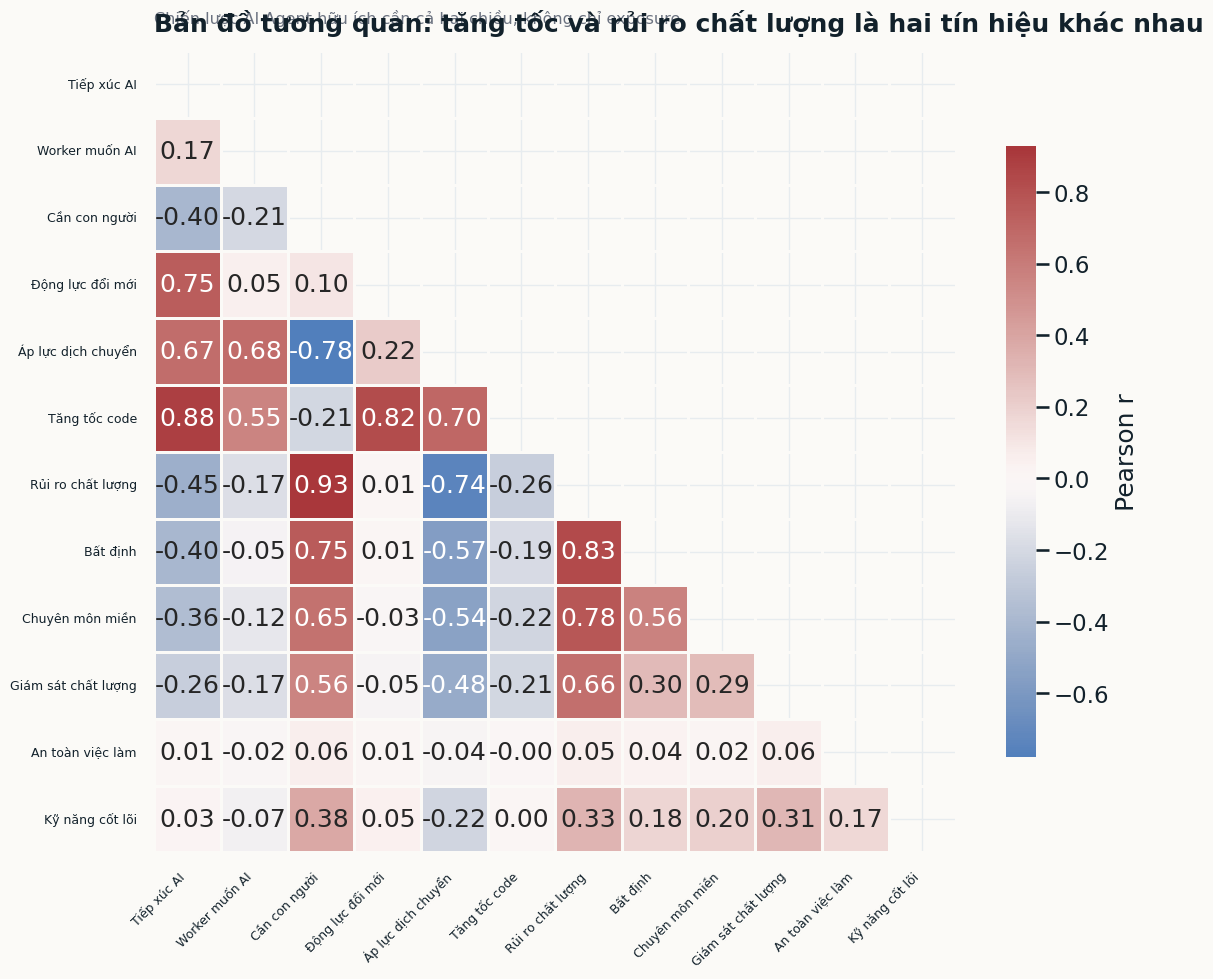

In [35]:
heat_cols = [
    'automation_exposure_index','worker_pull_index','human_complementarity_index','innovation_momentum_index',
    'skill_shift_pressure','code_acceleration_potential','quality_risk_need',
    'expert_uncertainty_requirement','expert_domain_expertise_requirement','human_agency_quality_oversight_share',
    'job_security_score','core_skill_score'
]
heat = cs[heat_cols].corr(min_periods=20)
var_labels = {
    'automation_exposure_index': U('Ti\\u1ebfp x\\u00fac AI'),
    'worker_pull_index': U('Worker mu\\u1ed1n AI'),
    'human_complementarity_index': U('C\\u1ea7n con ng\\u01b0\\u1eddi'),
    'innovation_momentum_index': U('\\u0110\\u1ed9ng l\\u1ef1c \\u0111\\u1ed5i m\\u1edbi'),
    'skill_shift_pressure': U('\\u00c1p l\\u1ef1c d\\u1ecbch chuy\\u1ec3n'),
    'code_acceleration_potential': U('T\\u0103ng t\\u1ed1c code'),
    'quality_risk_need': U('R\\u1ee7i ro ch\\u1ea5t l\\u01b0\\u1ee3ng'),
    'expert_uncertainty_requirement': U('B\\u1ea5t \\u0111\\u1ecbnh'),
    'expert_domain_expertise_requirement': U('Chuy\\u00ean m\\u00f4n mi\\u1ec1n'),
    'human_agency_quality_oversight_share': U('Gi\\u00e1m s\\u00e1t ch\\u1ea5t l\\u01b0\\u1ee3ng'),
    'job_security_score': U('An to\\u00e0n vi\\u1ec7c l\\u00e0m'),
    'core_skill_score': U('K\\u1ef9 n\\u0103ng c\\u1ed1t l\\u00f5i')
}
heat = heat.rename(index=var_labels, columns=var_labels)
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(heat, dtype=bool))
sns.heatmap(heat, mask=mask, cmap='vlag', center=0, annot=True, fmt='.2f', square=True,
            linewidths=.8, linecolor=PALETTE['paper'], cbar_kws={'shrink': .75, 'label': 'Pearson r'}, ax=ax)
title(ax, U('B\\u1ea3n \\u0111\\u1ed3 t\\u01b0\\u01a1ng quan: t\\u0103ng t\\u1ed1c v\\u00e0 r\\u1ee7i ro ch\\u1ea5t l\\u01b0\\u1ee3ng l\\u00e0 hai t\\u00edn hi\\u1ec7u kh\\u00e1c nhau'),
      U('Chi\\u1ebfn l\\u01b0\\u1ee3c AI Agent h\\u1eefu \\u00edch c\\u1ea7n c\\u1ea3 hai chi\\u1ec1u, kh\\u00f4ng ch\\u1ec9 exposure'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
savefig(fig, '06_correlation_heatmap.png')
plt.show()

**Insight 7.** Tương quan giúp kiểm tra phân tích đang đo một nhân tố đơn giản hay hai lực kéo khác nhau. Quy tắc quyết định thực tế nên kết hợp cả cơ hội tăng tốc và nhu cầu kiểm soát chất lượng.

## 9. Hồi quy: yếu tố nào làm tăng nhu cầu review/quality gate?

Phần này dùng hồi quy theo hướng **khám phá**, không diễn giải nhân quả. Mục tiêu là kiểm tra các tín hiệu nào liên quan mạnh hơn đến:

1. `quality_risk_need`: nhu cầu kiểm soát chất lượng, review, test và giám sát con người.
2. `Copilot + review bắt buộc`: xác suất một task nên dùng copilot kèm review thay vì agent tự động.

Hai mô hình được dùng:

- **OLS / hồi quy tuyến tính đa biến** cho biến liên tục `quality_risk_need`.
- **Logistic regression** cho biến nhị phân `needs_copilot_review`.

Các biến độc lập gồm: mức tiếp xúc AI, nhu cầu worker, mức cần con người, động lực đổi mới, độ bất định, yêu cầu chuyên môn miền và cờ `quality_critical_task`.


In [36]:
reg_features = [
    'automation_exposure_index',
    'worker_pull_index',
    'human_complementarity_index',
    'innovation_momentum_index',
    'expert_uncertainty_requirement',
    'expert_domain_expertise_requirement',
    'quality_critical_task'
]

reg_df = cs[reg_features + ['quality_risk_need', 'agent_recommendation']].copy()
reg_df['quality_critical_task'] = reg_df['quality_critical_task'].astype(int)
reg_df['needs_copilot_review'] = (reg_df['agent_recommendation'] == recommendation_order[1]).astype(int)
reg_df = reg_df.dropna(subset=reg_features + ['quality_risk_need'])

print('Regression sample size:', len(reg_df))
print('Copilot + review positive cases:', int(reg_df['needs_copilot_review'].sum()))

# Standardize predictors so coefficients are comparable.
X_raw = reg_df[reg_features].astype(float)
X_mean = X_raw.mean()
X_std = X_raw.std(ddof=0).replace(0, 1)
Xz = (X_raw - X_mean) / X_std
Xz_const = sm.add_constant(Xz)

# 1) OLS for quality_risk_need
ols_model = sm.OLS(reg_df['quality_risk_need'], Xz_const).fit(cov_type='HC3')
ols_coef = pd.DataFrame({
    'variable': ols_model.params.index,
    'coef': ols_model.params.values,
    'std_error': ols_model.bse.values,
    'p_value': ols_model.pvalues.values,
    'ci_low': ols_model.conf_int()[0].values,
    'ci_high': ols_model.conf_int()[1].values,
})
ols_coef = ols_coef[ols_coef['variable'] != 'const'].copy()
ols_coef['model'] = 'OLS: quality_risk_need'

# 2) Logistic regression for Copilot + review
logit_model = sm.Logit(reg_df['needs_copilot_review'], Xz_const).fit(disp=False, maxiter=200)
logit_coef = pd.DataFrame({
    'variable': logit_model.params.index,
    'coef': logit_model.params.values,
    'std_error': logit_model.bse.values,
    'p_value': logit_model.pvalues.values,
    'ci_low': logit_model.conf_int()[0].values,
    'ci_high': logit_model.conf_int()[1].values,
})
logit_coef = logit_coef[logit_coef['variable'] != 'const'].copy()
logit_coef['odds_ratio'] = np.exp(logit_coef['coef'])
logit_coef['odds_ci_low'] = np.exp(logit_coef['ci_low'])
logit_coef['odds_ci_high'] = np.exp(logit_coef['ci_high'])
logit_coef['model'] = 'Logit: Copilot + review'

var_vi = {
    'automation_exposure_index': U('M\\u1ee9c ti\\u1ebfp x\\u00fac AI'),
    'worker_pull_index': U('Worker mu\\u1ed1n AI'),
    'human_complementarity_index': U('M\\u1ee9c c\\u1ea7n con ng\\u01b0\\u1eddi'),
    'innovation_momentum_index': U('\\u0110\\u1ed9ng l\\u1ef1c \\u0111\\u1ed5i m\\u1edbi'),
    'expert_uncertainty_requirement': U('\\u0110\\u1ed9 b\\u1ea5t \\u0111\\u1ecbnh'),
    'expert_domain_expertise_requirement': U('Y\\u00eau c\\u1ea7u chuy\\u00ean m\\u00f4n mi\\u1ec1n'),
    'quality_critical_task': U('Task critical v\\u1ec1 ch\\u1ea5t l\\u01b0\\u1ee3ng')
}
ols_coef['variable_vi'] = ols_coef['variable'].map(var_vi)
logit_coef['variable_vi'] = logit_coef['variable'].map(var_vi)

ols_coef.to_csv(OUT / 'cs_regression_quality_risk_ols.csv', index=False, encoding='utf-8-sig')
logit_coef.to_csv(OUT / 'cs_regression_copilot_review_logit.csv', index=False, encoding='utf-8-sig')

print('\nOLS summary metrics')
print({'r_squared': round(ols_model.rsquared, 3), 'adj_r_squared': round(ols_model.rsquared_adj, 3)})
print('\nLogit summary metrics')
print({'pseudo_r2': round(logit_model.prsquared, 3), 'aic': round(logit_model.aic, 1)})

display(ols_coef[['variable_vi','coef','p_value','ci_low','ci_high']].sort_values('coef', ascending=False).round(3))
display(logit_coef[['variable_vi','coef','odds_ratio','p_value','odds_ci_low','odds_ci_high']].sort_values('coef', ascending=False).round(3))

Regression sample size: 173
Copilot + review positive cases: 40

OLS summary metrics
{'r_squared': 0.946, 'adj_r_squared': 0.944}

Logit summary metrics
{'pseudo_r2': 0.715, 'aic': 69.3}


,variable_vi,coef,p_value,ci_low,ci_high
3,Mức cần con người,0.099,0.000,0.089,0.110
6,Yêu cầu chuyên môn miền,0.046,0.000,0.038,0.054
5,Độ bất định,0.045,0.000,0.035,0.056
1,Mức tiếp xúc AI,0.003,0.521,-0.007,0.014
2,Worker muốn AI,-0.001,0.752,-0.008,0.006
7,Task critical về chất lượng,-0.001,0.694,-0.008,0.005
4,Động lực đổi mới,-0.009,0.040,-0.018,-0.000


,variable_vi,coef,odds_ratio,p_value,odds_ci_low,odds_ci_high
2,Worker muốn AI,5.211,183.204,0.000,18.363,1827.757
1,Mức tiếp xúc AI,3.568,35.448,0.000,4.985,252.080
4,Động lực đổi mới,3.288,26.790,0.004,2.784,257.825
7,Task critical về chất lượng,1.247,3.480,0.007,1.403,8.632
3,Mức cần con người,0.946,2.576,0.207,0.592,11.213
6,Yêu cầu chuyên môn miền,0.287,1.333,0.623,0.424,4.190
5,Độ bất định,-0.246,0.782,0.700,0.223,2.736


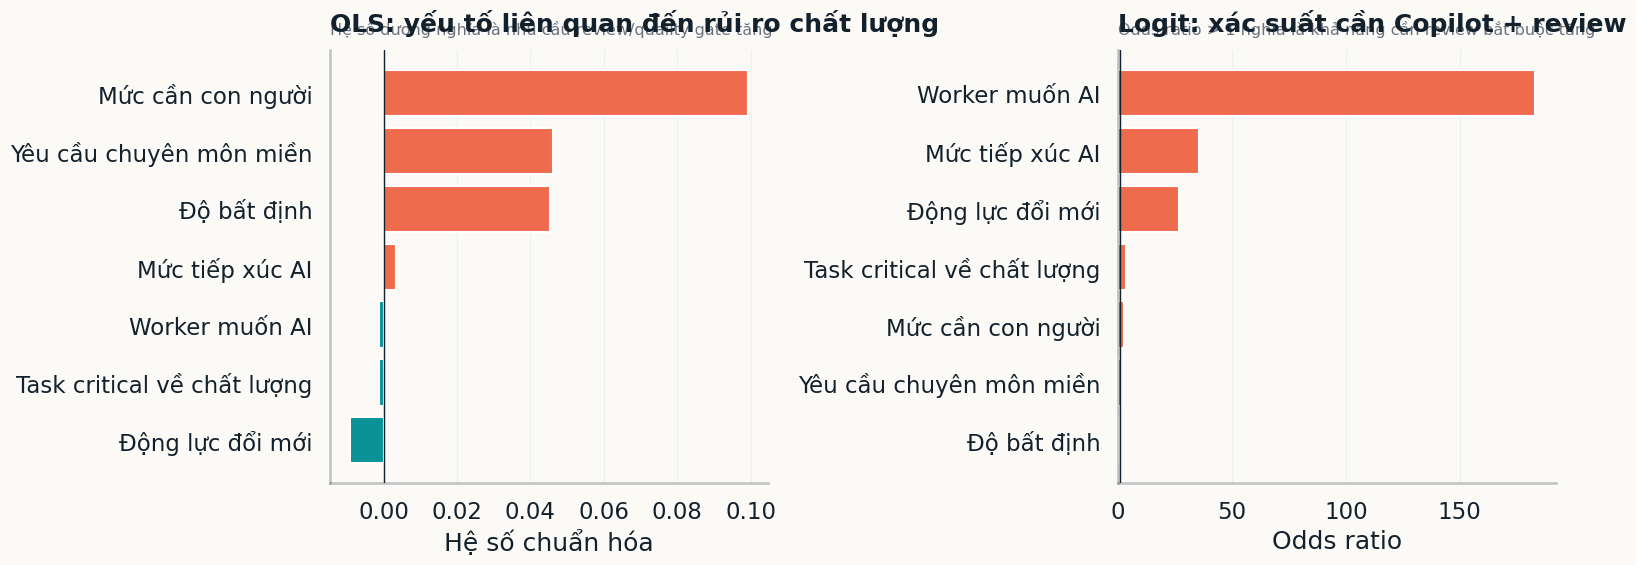

In [37]:
# Coefficient plots for report-ready interpretation.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ols_plot = ols_coef.sort_values('coef')
axes[0].barh(ols_plot['variable_vi'], ols_plot['coef'], color=[PALETTE['coral'] if x > 0 else PALETTE['teal'] for x in ols_plot['coef']])
axes[0].axvline(0, color=PALETTE['ink'], lw=1)
axes[0].set_xlabel(U(r'H\u1ec7 s\u1ed1 chu\u1ea9n h\u00f3a'))
axes[0].set_ylabel('')
title(axes[0], U(r'OLS: y\u1ebfu t\u1ed1 li\u00ean quan \u0111\u1ebfn r\u1ee7i ro ch\u1ea5t l\u01b0\u1ee3ng'),
      U(r'H\u1ec7 s\u1ed1 d\u01b0\u01a1ng ngh\u0129a l\u00e0 nhu c\u1ea7u review/quality gate t\u0103ng'))
clean_axis(axes[0], xgrid=True)

logit_plot = logit_coef.sort_values('coef')
axes[1].barh(logit_plot['variable_vi'], logit_plot['odds_ratio'], color=[PALETTE['coral'] if x > 1 else PALETTE['teal'] for x in logit_plot['odds_ratio']])
axes[1].axvline(1, color=PALETTE['ink'], lw=1)
axes[1].set_xlabel(U(r'Odds ratio'))
axes[1].set_ylabel('')
title(axes[1], U(r'Logit: x\u00e1c su\u1ea5t c\u1ea7n Copilot + review'),
      U(r'Odds ratio > 1 ngh\u0129a l\u00e0 kh\u1ea3 n\u0103ng c\u1ea7n review b\u1eaft bu\u1ed9c t\u0103ng'))
clean_axis(axes[1], xgrid=True)

plt.tight_layout()
savefig(fig, '08_regression_coefficients.png')
plt.show()


**Insight hồi quy.** Mô hình OLS giúp đọc yếu tố nào gắn với `quality_risk_need`, còn mô hình logistic giúp đọc yếu tố nào làm tăng khả năng một task cần `Copilot + review bắt buộc`. Nếu `quality_critical_task`, `human_complementarity_index`, `expert_uncertainty_requirement` hoặc `expert_domain_expertise_requirement` có hệ số dương, điều đó ủng hộ luận điểm: khi AI tăng tốc output, kỹ năng quan trọng dịch sang review, test, xử lý bất định và kiểm soát chất lượng.

Cách viết trong báo cáo:

> Hồi quy logistic được dùng để ước lượng xác suất một task cần cơ chế `Copilot + review bắt buộc`. Kết quả không được diễn giải như quan hệ nhân quả, mà như bằng chứng khám phá cho thấy các task có tính critical, bất định cao hoặc cần chuyên môn miền có xu hướng cần quality gate mạnh hơn khi triển khai AI Agent.


## 10. Bảng evidence examples

Bảng này giúp báo cáo dễ thuyết phục hơn: tách riêng task có tiềm năng tăng tốc cao, task có rủi ro chất lượng cao, và task nên dùng copilot kèm review. Đây là bằng chứng cụ thể cho luận điểm: AI có thể tăng output, nhưng quality gate/review/test trở thành kỹ năng trung tâm.


In [38]:
evidence_frames = []
cols = ['Task ID','Occupation (O*NET-SOC Title)','Task','task_group_vi','quality_critical_task','code_acceleration_potential','quality_risk_need','agent_recommendation']

def add_examples(label, frame):
    temp = frame[cols].copy()
    temp.insert(0, 'evidence_group', label)
    evidence_frames.append(temp)

add_examples(U('Ti\\u1ec1m n\\u0103ng t\\u0103ng t\\u1ed1c code cao'), cs.sort_values('code_acceleration_potential', ascending=False).head(8))
add_examples(U('Nhu c\\u1ea7u ki\\u1ec3m so\\u00e1t ch\\u1ea5t l\\u01b0\\u1ee3ng cao'), cs.sort_values('quality_risk_need', ascending=False).head(8))
add_examples(U('N\\u00ean d\\u00f9ng copilot + review'), cs[cs['agent_recommendation'].eq(recommendation_order[1])].sort_values(['code_acceleration_potential','quality_risk_need'], ascending=False).head(8))

evidence_examples = pd.concat(evidence_frames, ignore_index=True)
evidence_examples.to_csv(OUT / 'cs_evidence_examples.csv', index=False, encoding='utf-8-sig')
evidence_examples.round(3)

,evidence_group,Task ID,Occupation (O*NET-SOC Title),Task,task_group_vi,quality_critical_task,code_acceleration_potential,quality_risk_need,agent_recommendation
0,Tiềm năng tăng tốc code cao,14661,Software Quality Assurance Analysts and Testers,"Perform initial debugging procedures by reviewing configuration files, logs, or code pieces to determine breakdown s...",Kiểm thử / QA / review,True,0.986,NaN,Cần thêm dữ liệu
1,Tiềm năng tăng tốc code cao,14677,Computer Systems Engineers/Architects,"Investigate system component suitability for specified purposes, and make recommendations regarding component use.",Kiến trúc / quản trị,True,0.981,NaN,Cần thêm dữ liệu
2,Tiềm năng tăng tốc code cao,7380,Operations Research Analysts,"Perform validation and testing of models to ensure adequacy, and reformulate models, as necessary.",Kiểm thử / QA / review,True,0.934,NaN,Cần thêm dữ liệu
3,Tiềm năng tăng tốc code cao,7382,Operations Research Analysts,"Define data requirements, and gather and validate information, applying judgment and statistical tests.",Kiểm thử / QA / review,True,0.926,NaN,Cần thêm dữ liệu
4,Tiềm năng tăng tốc code cao,7377,Operations Research Analysts,"Formulate mathematical or simulation models of problems, relating constants and variables, restrictions, alternative...",Kiến trúc / quản trị,False,0.924,NaN,Cần thêm dữ liệu
5,Tiềm năng tăng tốc code cao,7385,Operations Research Analysts,"Break systems into their components, assign numerical values to each component, and examine the mathematical relatio...",Kiến trúc / quản trị,False,0.915,NaN,Cần thêm dữ liệu
6,Tiềm năng tăng tốc code cao,17716,Bioinformatics Technicians,Maintain awareness of new and emerging computational methods and technologies.,Task CS khác,False,0.907,NaN,Cần thêm dữ liệu
7,Tiềm năng tăng tốc code cao,14763,Web Administrators,Develop testing routines and procedures.,Kiểm thử / QA / review,True,0.907,NaN,Cần thêm dữ liệu
8,Nhu cầu kiểm soát chất lượng cao,1319,Network and Computer Systems Administrators,"Plan, coordinate, and implement network security measures to protect data, software, and hardware.",Kiểm thử / QA / review,True,0.692,0.844,"Con người dẫn dắt, AI hỗ trợ"
9,Nhu cầu kiểm soát chất lượng cao,1317,Network and Computer Systems Administrators,Perform data backups and disaster recovery operations.,Kiến trúc / quản trị,True,0.650,0.832,"Con người dẫn dắt, AI hỗ trợ"


## 9. Bảng khuyến nghị theo task

In [39]:
recommendation_table = cs[[
    'Task ID','Occupation (O*NET-SOC Title)','Task','task_group','task_group_vi','quality_critical_task',
    'automation_exposure_index','worker_pull_index','human_complementarity_index','innovation_momentum_index',
    'skill_shift_pressure','code_acceleration_potential','quality_risk_need','transition_type','mismatch_type','agent_recommendation'
]].copy()

def rationale(row):
    rec = row['agent_recommendation']
    if rec == recommendation_order[0]:
        return U('T\\u00edn hi\\u1ec7u AI/innovation cao v\\u00e0 r\\u1ee7i ro ch\\u1ea5t l\\u01b0\\u1ee3ng th\\u1ea5p h\\u01a1n; c\\u1ea7n logging, test v\\u00e0 rollback.')
    if rec == recommendation_order[1]:
        return U('AI c\\u00f3 th\\u1ec3 t\\u0103ng t\\u1ed1c output, nh\\u01b0ng r\\u1ee7i ro ch\\u1ea5t l\\u01b0\\u1ee3ng ho\\u1eb7c t\\u00ednh critical \\u0111\\u00f2i h\\u1ecfi code review, test v\\u00e0 ph\\u00ea duy\\u1ec7t con ng\\u01b0\\u1eddi.')
    if rec == recommendation_order[2]:
        return U('Ph\\u00e1n \\u0111o\\u00e1n con ng\\u01b0\\u1eddi v\\u1eabn l\\u00e0 trung t\\u00e2m; AI n\\u00ean h\\u1ed7 tr\\u1ee3 checklist, t\\u00f3m t\\u1eaft v\\u00e0 ph\\u00e2n t\\u00edch nh\\u00e1p.')
    if rec == recommendation_order[3]:
        return U('T\\u00edn hi\\u1ec7u ch\\u01b0a \\u0111\\u1ee7 m\\u1ea1nh \\u0111\\u1ec3 \\u01b0u ti\\u00ean t\\u1ef1 \\u0111\\u1ed9ng h\\u00f3a; n\\u00ean th\\u1eed nghi\\u1ec7m nh\\u1ecf ho\\u1eb7c theo d\\u00f5i th\\u00eam.')
    return U('Thi\\u1ebfu b\\u1eb1ng ch\\u1ee9ng worker/expert ho\\u1eb7c ch\\u1ec9 s\\u1ed1 ch\\u00ednh; c\\u1ea7n thu th\\u1eadp th\\u00eam d\\u1eef li\\u1ec7u tr\\u01b0\\u1edbc khi khuy\\u1ebfn ngh\\u1ecb.')

recommendation_table['recommendation_rationale'] = recommendation_table.apply(rationale, axis=1)
recommendation_table = recommendation_table.sort_values(['agent_recommendation','code_acceleration_potential','quality_risk_need'], ascending=[True, False, False])
recommendation_table.to_csv(OUT / 'cs_agent_task_recommendations.csv', index=False, encoding='utf-8-sig')
group_summary.to_csv(OUT / 'cs_task_group_summary.csv', index=False, encoding='utf-8-sig')
occ_cs.to_csv(OUT / 'cs_occupation_agent_summary.csv', index=False, encoding='utf-8-sig')

examples = pd.concat([
    recommendation_table[recommendation_table['agent_recommendation'].eq(recommendation_order[0])].head(5),
    recommendation_table[recommendation_table['agent_recommendation'].eq(recommendation_order[1])].head(8),
    recommendation_table[recommendation_table['agent_recommendation'].eq(recommendation_order[2])].head(5),
])
examples[['Occupation (O*NET-SOC Title)','Task','task_group_vi','quality_critical_task','code_acceleration_potential','quality_risk_need','agent_recommendation','recommendation_rationale']].round(3)

,Occupation (O*NET-SOC Title),Task,task_group_vi,quality_critical_task,code_acceleration_potential,quality_risk_need,agent_recommendation,recommendation_rationale
543,Computer Programmers,"Compile and write documentation of program development and subsequent revisions, inserting comments in the coded ins...",Sinh code / phát triển,False,0.879,0.164,Agent bán tự động,"Tín hiệu AI/innovation cao và rủi ro chất lượng thấp hơn; cần logging, test và rollback."
568,Web Developers,Write supporting code for Web applications or Web sites.,Sinh code / phát triển,False,0.823,0.256,Agent bán tự động,"Tín hiệu AI/innovation cao và rủi ro chất lượng thấp hơn; cần logging, test và rollback."
684,Business Intelligence Analysts,"Maintain library of model documents, templates, or other reusable knowledge assets.",Kiến trúc / quản trị,False,0.815,0.229,Agent bán tự động,"Tín hiệu AI/innovation cao và rủi ro chất lượng thấp hơn; cần logging, test và rollback."
539,Computer Programmers,Correct errors by making appropriate changes and rechecking the program to ensure that the desired results are produ...,Sinh code / phát triển,False,0.814,0.282,Agent bán tự động,"Tín hiệu AI/innovation cao và rủi ro chất lượng thấp hơn; cần logging, test và rollback."
542,Computer Programmers,"Prepare detailed workflow charts and diagrams that describe input, output, and logical operation, and convert them i...",Sinh code / phát triển,False,0.804,0.138,Agent bán tự động,"Tín hiệu AI/innovation cao và rủi ro chất lượng thấp hơn; cần logging, test và rollback."
640,Computer Systems Engineers/Architects,"Research, test, or verify proper functioning of software patches and fixes.",Kiểm thử / QA / review,True,0.870,0.480,Copilot + review bắt buộc,"AI có thể tăng tốc output, nhưng rủi ro chất lượng hoặc tính critical đòi hỏi code review, test và phê duyệt con người."
598,Web Administrators,Back up or modify applications and related data to provide for disaster recovery.,Sinh code / phát triển,True,0.863,0.214,Copilot + review bắt buộc,"AI có thể tăng tốc output, nhưng rủi ro chất lượng hoặc tính critical đòi hỏi code review, test và phê duyệt con người."
448,Computer Systems Analysts,"Review and analyze computer printouts and performance indicators to locate code problems, and correct errors by corr...",Kiểm thử / QA / review,True,0.859,0.353,Copilot + review bắt buộc,"AI có thể tăng tốc output, nhưng rủi ro chất lượng hoặc tính critical đòi hỏi code review, test và phê duyệt con người."
552,Software Quality Assurance Analysts and Testers,"Design test plans, scenarios, scripts, or procedures.",Kiểm thử / QA / review,True,0.855,0.403,Copilot + review bắt buộc,"AI có thể tăng tốc output, nhưng rủi ro chất lượng hoặc tính critical đòi hỏi code review, test và phê duyệt con người."
638,Computer Systems Engineers/Architects,Monitor system operation to detect potential problems.,Kiểm thử / QA / review,True,0.846,0.656,Copilot + review bắt buộc,"AI có thể tăng tốc output, nhưng rủi ro chất lượng hoặc tính critical đòi hỏi code review, test và phê duyệt con người."


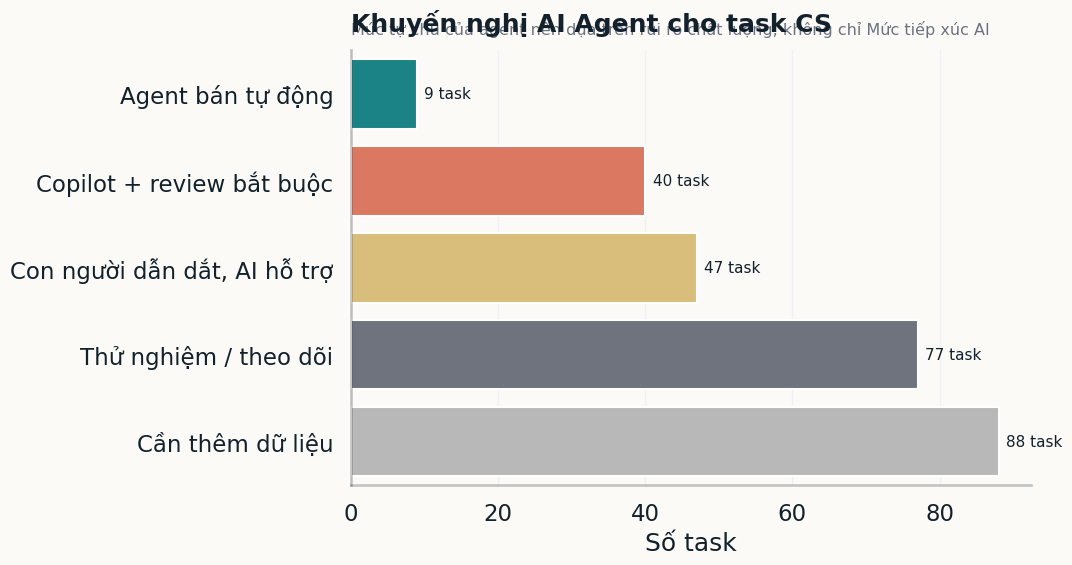

In [40]:
rec_counts = cs['agent_recommendation'].value_counts().reindex(recommendation_order).dropna().reset_index()
rec_counts.columns = ['agent_recommendation','task_count']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=rec_counts, y='agent_recommendation', x='task_count', palette=[rec_colors[x] for x in rec_counts['agent_recommendation']], ax=ax)
for i, row in rec_counts.iterrows():
    ax.text(row['task_count'] + 1, i, f"{int(row['task_count'])} task", va='center', fontsize=11, color=PALETTE['ink'])
title(ax, 'Khuyến nghị AI Agent cho task CS',
      'Mức tự chủ của agent nên dựa trên rủi ro chất lượng, không chỉ Mức tiếp xúc AI')
ax.set_xlabel('Số task')
ax.set_ylabel('')
clean_axis(ax, xgrid=True)
plt.tight_layout()
savefig(fig, '07_agent_recommendation_counts.png')
plt.show()

## Giới hạn phân tích

- Notebook **không chứng minh trực tiếp** rằng AI làm chất lượng code giảm, vì dữ liệu không có defect rate, bug production, failed CI, review rejection hay maintainability score.
- `quality_risk_need` là **proxy** cho nhu cầu kiểm soát chất lượng, không phải metric chất lượng code thật.
- PCA là phân tích khám phá cấu trúc dữ liệu, không chứng minh quan hệ nhân quả.
- Một số occupation/task thiếu tín hiệu worker hoặc expert; các trường hợp này nên đọc là `Cần thêm dữ liệu`, không nên kết luận mạnh.

Cách diễn giải an toàn hơn là: **AI có thể tăng tốc tạo code/output kỹ thuật, nhưng đồng thời làm kỹ năng review, test, giám sát chất lượng và quản trị AI Agent trở nên quan trọng hơn.**


## 13. Skill Shift Pathway: kỹ năng cũ dịch sang kỹ năng mới như thế nào?

Các phần trước cho thấy AI có thể tăng tốc output code nhưng làm quality gate/review/test quan trọng hơn. Phần này chuyển kết quả phân tích thành câu hỏi kỹ năng:

> Khi AI Agent tham gia workflow lập trình, người lao động cần dịch từ kỹ năng nào sang kỹ năng nào?

Đây là phần nối trực tiếp giữa phân tích dữ liệu và khuyến nghị đào tạo lại (`reskilling`).


In [41]:
skill_pathway = pd.DataFrame([
    {
        'before_ai': U('T\\u1ef1 vi\\u1ebft code t\\u1eeb \\u0111\\u1ea7u'),
        'ai_augmented_work': U('AI t\\u1ea1o b\\u1ea3n nh\\u00e1p code'),
        'human_premium_skill': U('Review code, ki\\u1ec3m ch\\u1ee9ng logic, ch\\u1ecbu tr\\u00e1ch nhi\\u1ec7m ch\\u1ea5t l\\u01b0\\u1ee3ng'),
        'related_task_group': group_labels['Code generation / development']
    },
    {
        'before_ai': U('Vi\\u1ebft test th\\u1ee7 c\\u00f4ng'),
        'ai_augmented_work': U('AI g\\u1ee3i \\u00fd test case v\\u00e0 edge case'),
        'human_premium_skill': U('Thi\\u1ebft k\\u1ebf chi\\u1ebfn l\\u01b0\\u1ee3c test, ch\\u1ecdn case quan tr\\u1ecdng'),
        'related_task_group': group_labels['Quality control / QA / review']
    },
    {
        'before_ai': U('Debug b\\u1eb1ng kinh nghi\\u1ec7m c\\u00e1 nh\\u00e2n'),
        'ai_augmented_work': U('AI \\u0111\\u1ecdc log v\\u00e0 g\\u1ee3i \\u00fd nguy\\u00ean nh\\u00e2n l\\u1ed7i'),
        'human_premium_skill': U('Root-cause validation, ki\\u1ec3m ch\\u1ee9ng gi\\u1ea3 thuy\\u1ebft l\\u1ed7i'),
        'related_task_group': group_labels['Quality control / QA / review']
    },
    {
        'before_ai': U('Vi\\u1ebft t\\u00e0i li\\u1ec7u k\\u1ef9 thu\\u1eadt'),
        'ai_augmented_work': U('AI t\\u1ea1o draft t\\u00e0i li\\u1ec7u'),
        'human_premium_skill': U('Ki\\u1ec3m tra \\u0111\\u1ed9 ch\\u00ednh x\\u00e1c k\\u1ef9 thu\\u1eadt v\\u00e0 compliance'),
        'related_task_group': group_labels['Documentation / reporting']
    },
    {
        'before_ai': U('Thi\\u1ebft k\\u1ebf h\\u1ec7 th\\u1ed1ng th\\u1ee7 c\\u00f4ng'),
        'ai_augmented_work': U('AI g\\u1ee3i \\u00fd ph\\u01b0\\u01a1ng \\u00e1n ki\\u1ebfn tr\\u00fac'),
        'human_premium_skill': U('\\u0110\\u00e1nh gi\\u00e1 trade-off, b\\u1ea3o m\\u1eadt, maintainability'),
        'related_task_group': group_labels['Architecture / governance']
    },
    {
        'before_ai': U('L\\u00e0m t\\u1eebng task ri\\u00eang l\\u1ebb'),
        'ai_augmented_work': U('\\u0110i\\u1ec1u ph\\u1ed1i nhi\\u1ec1u agent/tool trong workflow'),
        'human_premium_skill': U('Agent orchestration, quality gate, rollback'),
        'related_task_group': group_labels['Other CS tasks']
    },
])

skill_pathway.to_csv(OUT / 'cs_skill_shift_pathway.csv', index=False, encoding='utf-8-sig')
skill_pathway

,before_ai,ai_augmented_work,human_premium_skill,related_task_group
0,Tự viết code từ đầu,AI tạo bản nháp code,"Review code, kiểm chứng logic, chịu trách nhiệm chất lượng",Sinh code / phát triển
1,Viết test thủ công,AI gợi ý test case và edge case,"Thiết kế chiến lược test, chọn case quan trọng",Kiểm thử / QA / review
2,Debug bằng kinh nghiệm cá nhân,AI đọc log và gợi ý nguyên nhân lỗi,"Root-cause validation, kiểm chứng giả thuyết lỗi",Kiểm thử / QA / review
3,Viết tài liệu kỹ thuật,AI tạo draft tài liệu,Kiểm tra độ chính xác kỹ thuật và compliance,Tài liệu / báo cáo
4,Thiết kế hệ thống thủ công,AI gợi ý phương án kiến trúc,"Đánh giá trade-off, bảo mật, maintainability",Kiến trúc / quản trị
5,Làm từng task riêng lẻ,Điều phối nhiều agent/tool trong workflow,"Agent orchestration, quality gate, rollback",Task CS khác


In [42]:
# Reskilling priority: where AI acceleration and human quality control are both important.
# This is a relative score for prioritizing training, not a causal estimate.
cs['reskilling_priority_score'] = (
    0.40 * cs['code_acceleration_potential']
    + 0.35 * cs['quality_risk_need']
    + 0.25 * cs['human_complementarity_index']
)

reskill_occ = (cs.groupby('Occupation (O*NET-SOC Title)')
    .agg(task_count=('Task ID','count'),
         code_acceleration_potential=('code_acceleration_potential','mean'),
         quality_risk_need=('quality_risk_need','mean'),
         human_complementarity_index=('human_complementarity_index','mean'),
         reskilling_priority_score=('reskilling_priority_score','mean'),
         critical_task_share=('quality_critical_task','mean'))
    .reset_index())
reskill_occ = reskill_occ[reskill_occ['task_count'] >= 4].sort_values('reskilling_priority_score', ascending=False)

reskill_group = (cs.groupby('task_group_vi')
    .agg(task_count=('Task ID','count'),
         code_acceleration_potential=('code_acceleration_potential','mean'),
         quality_risk_need=('quality_risk_need','mean'),
         human_complementarity_index=('human_complementarity_index','mean'),
         reskilling_priority_score=('reskilling_priority_score','mean'),
         critical_task_share=('quality_critical_task','mean'))
    .reindex(group_order_vi)
    .reset_index())

reskill_task = cs[[
    'Task ID','Occupation (O*NET-SOC Title)','Task','task_group_vi','quality_critical_task',
    'code_acceleration_potential','quality_risk_need','human_complementarity_index','reskilling_priority_score',
    'agent_recommendation'
]].sort_values('reskilling_priority_score', ascending=False)

reskill_occ.to_csv(OUT / 'cs_reskilling_priority_by_occupation.csv', index=False, encoding='utf-8-sig')
reskill_group.to_csv(OUT / 'cs_reskilling_priority_by_task_group.csv', index=False, encoding='utf-8-sig')
reskill_task.to_csv(OUT / 'cs_reskilling_priority_by_task.csv', index=False, encoding='utf-8-sig')

display(reskill_group.round(3))
display(reskill_occ.head(12).round(3))

,task_group_vi,task_count,code_acceleration_potential,quality_risk_need,human_complementarity_index,reskilling_priority_score,critical_task_share
0,Sinh code / phát triển,83,0.715,0.394,0.471,0.542,0.337
1,Kiểm thử / QA / review,88,0.704,0.448,0.539,0.570,0.932
2,Kiến trúc / quản trị,52,0.630,0.428,0.517,0.529,0.423
3,Tài liệu / báo cáo,16,0.678,0.395,0.439,0.536,0.000
4,Task CS khác,22,0.651,0.488,0.536,0.571,0.045


,Occupation (O*NET-SOC Title),task_count,code_acceleration_potential,quality_risk_need,human_complementarity_index,reskilling_priority_score,critical_task_share
9,Computer Systems Engineers/Architects,11,0.760,0.595,0.740,0.689,1.000
11,Computer and Information Research Scientists,6,0.772,0.565,0.709,0.684,0.000
19,Information Technology Project Managers,8,0.654,0.567,0.729,0.642,0.250
4,Clinical Data Managers,7,0.723,0.525,0.625,0.629,0.286
3,Business Intelligence Analysts,6,0.768,0.448,0.542,0.600,0.167
24,Statisticians,6,0.708,0.496,0.553,0.595,0.000
2,Biostatisticians,7,0.641,0.522,0.569,0.582,0.143
18,Information Security Analysts,5,0.549,0.559,0.612,0.569,1.000
20,Mathematicians,5,0.659,0.500,0.513,0.567,0.000
21,Network and Computer Systems Administrators,13,0.675,0.476,0.525,0.561,1.000


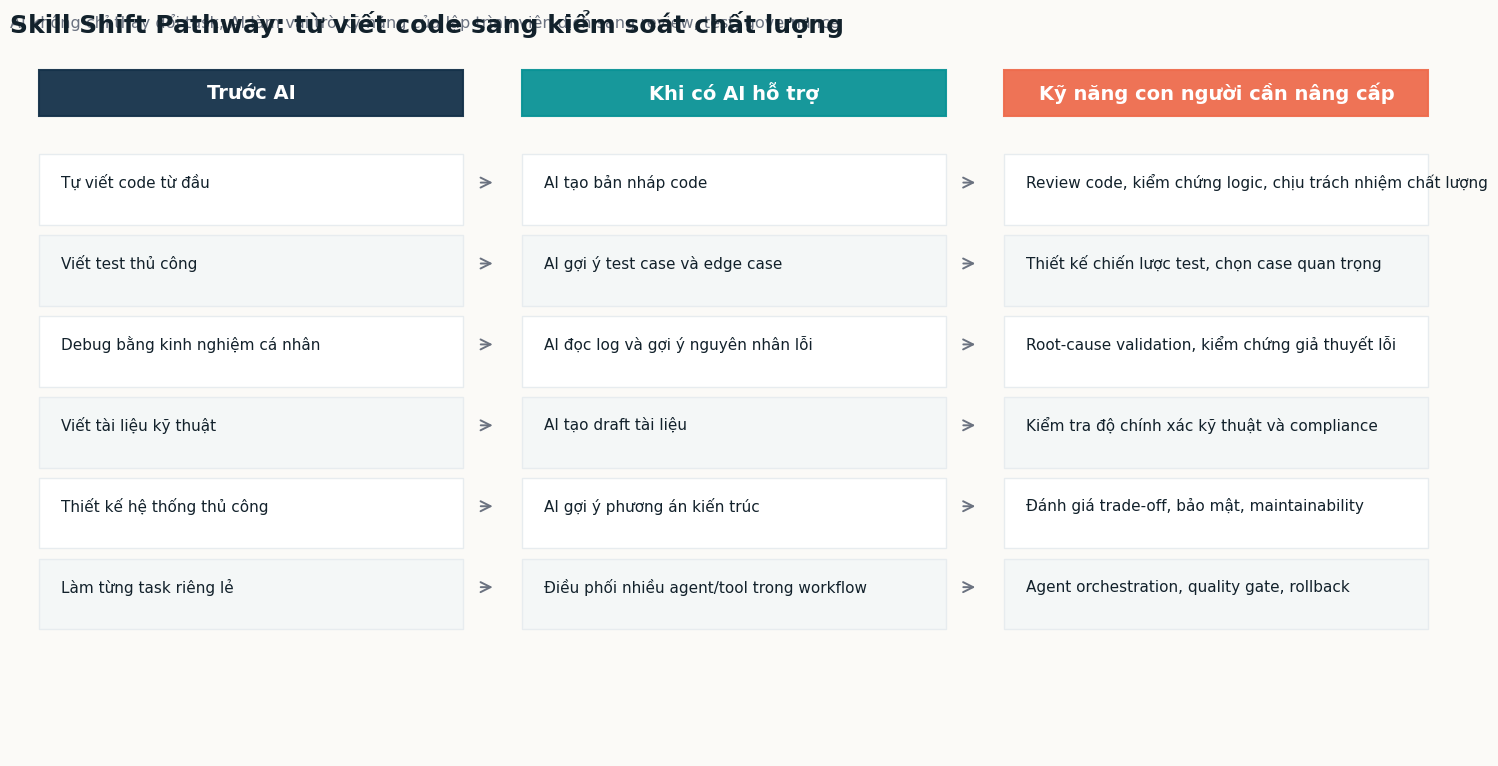

In [43]:
# Figure: skill shift pathway matrix.
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')
fig.patch.set_facecolor(PALETTE['paper'])

cols = [U('Tr\\u01b0\\u1edbc AI'), U('Khi c\\u00f3 AI h\\u1ed7 tr\\u1ee3'), U('K\\u1ef9 n\\u0103ng con ng\\u01b0\\u1eddi c\\u1ea7n n\\u00e2ng c\\u1ea5p')]
x_positions = [0.02, 0.35, 0.68]
width = 0.29
row_h = 0.115
y_top = 0.86

for x, col, color in zip(x_positions, cols, [PALETTE['navy'], PALETTE['teal'], PALETTE['coral']]):
    ax.add_patch(Rectangle((x, 0.91), width, 0.065, transform=ax.transAxes, color=color, alpha=0.95))
    ax.text(x + width/2, 0.942, col, transform=ax.transAxes, ha='center', va='center', color='white', fontsize=14, fontweight='bold')

for i, row in skill_pathway.iterrows():
    y = y_top - i*row_h
    fill = '#FFFFFF' if i % 2 == 0 else '#F4F7F7'
    for x in x_positions:
        ax.add_patch(Rectangle((x, y-row_h+0.01), width, row_h-0.015, transform=ax.transAxes, color=fill, ec=PALETTE['grid'], lw=1))
    ax.text(x_positions[0]+0.015, y-0.045, row['before_ai'], transform=ax.transAxes, ha='left', va='center', fontsize=11, wrap=True)
    ax.text(x_positions[1]+0.015, y-0.045, row['ai_augmented_work'], transform=ax.transAxes, ha='left', va='center', fontsize=11, wrap=True)
    ax.text(x_positions[2]+0.015, y-0.045, row['human_premium_skill'], transform=ax.transAxes, ha='left', va='center', fontsize=11, wrap=True)
    ax.annotate('', xy=(x_positions[1]-0.018, y-0.045), xytext=(x_positions[0]+width+0.01, y-0.045),
                xycoords=ax.transAxes, textcoords=ax.transAxes,
                arrowprops=dict(arrowstyle='->', color=PALETTE['muted'], lw=1.4))
    ax.annotate('', xy=(x_positions[2]-0.018, y-0.045), xytext=(x_positions[1]+width+0.01, y-0.045),
                xycoords=ax.transAxes, textcoords=ax.transAxes,
                arrowprops=dict(arrowstyle='->', color=PALETTE['muted'], lw=1.4))

title(ax, U('Skill Shift Pathway: t\\u1eeb vi\\u1ebft code sang ki\\u1ec3m so\\u00e1t ch\\u1ea5t l\\u01b0\\u1ee3ng'),
      U('AI kh\\u00f4ng ch\\u1ec9 thay \\u0111\\u1ed5i task; AI l\\u00e0m vai tr\\u00f2 k\\u1ef9 n\\u0103ng c\\u1ee7a l\\u1eadp tr\\u00ecnh vi\\u00ean d\\u1ecbch sang review, test, governance'))
plt.tight_layout()
savefig(fig, '09_skill_shift_pathway.png')
plt.show()

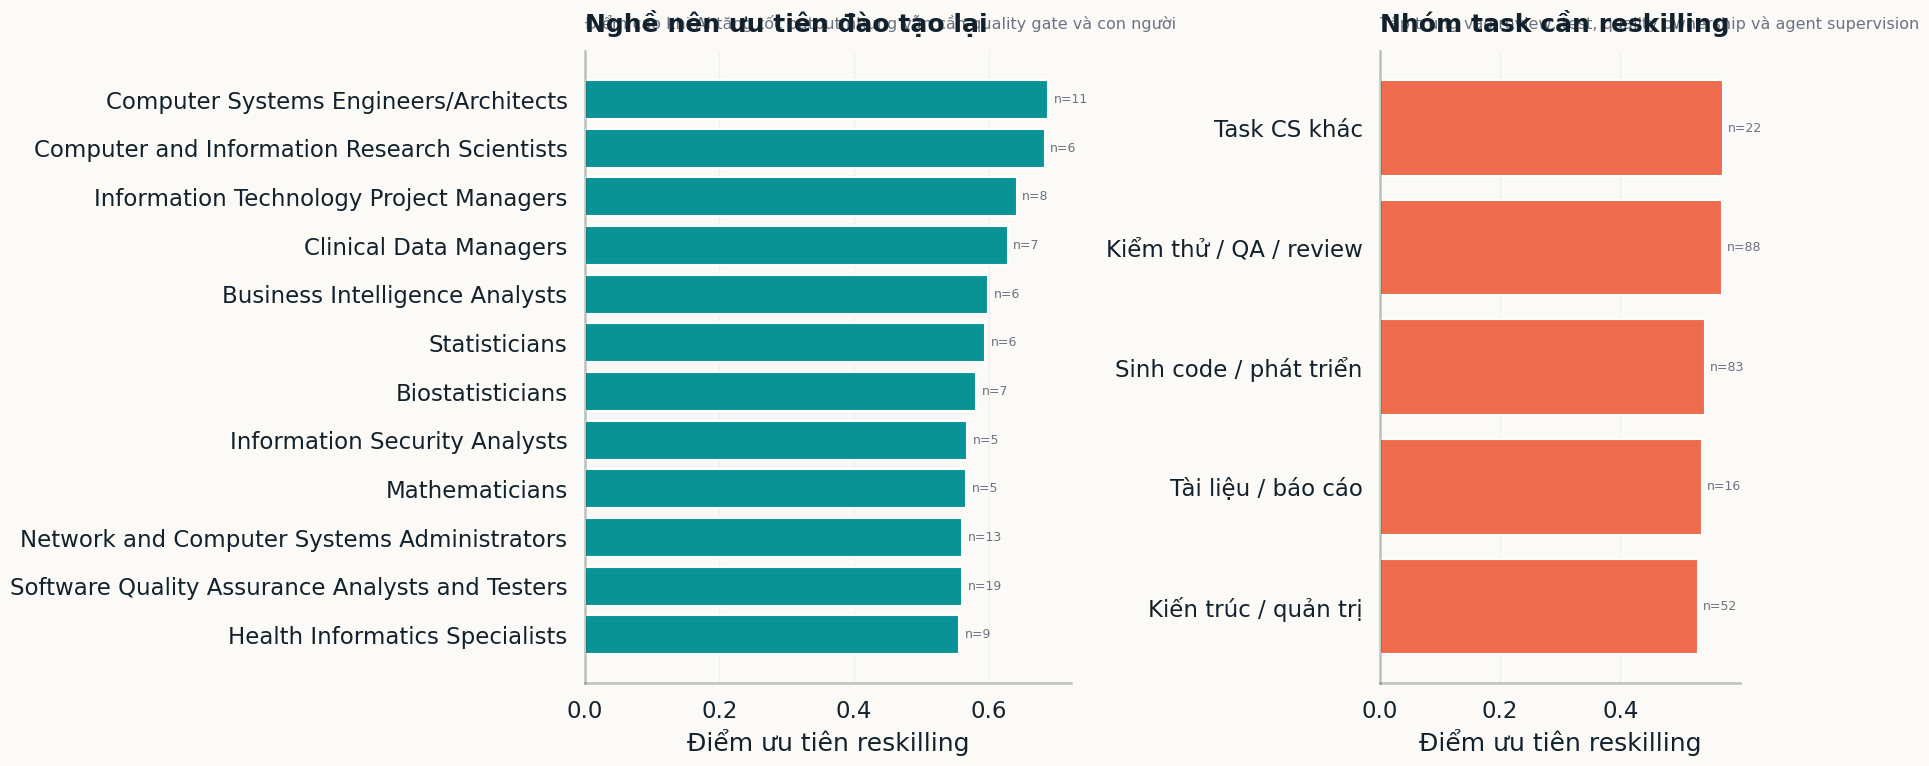

In [44]:
# Figure: reskilling priority by occupation and task group.
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.35, 1]})

top_reskill = reskill_occ.head(12).sort_values('reskilling_priority_score')
axes[0].barh(top_reskill['Occupation (O*NET-SOC Title)'], top_reskill['reskilling_priority_score'], color=PALETTE['teal'])
for i, row in enumerate(top_reskill.itertuples()):
    axes[0].text(row.reskilling_priority_score + 0.008, i, f"n={row.task_count}", va='center', fontsize=9, color=PALETTE['muted'])
axes[0].set_xlabel(U('\\u0110i\\u1ec3m \\u01b0u ti\\u00ean reskilling'))
axes[0].set_ylabel('')
title(axes[0], U('Ngh\\u1ec1 n\\u00ean \\u01b0u ti\\u00ean \\u0111\\u00e0o t\\u1ea1o l\\u1ea1i'),
      U('\\u0110i\\u1ec3m cao khi AI t\\u0103ng t\\u1ed1c output nh\\u01b0ng v\\u1eabn c\\u1ea7n quality gate v\\u00e0 con ng\\u01b0\\u1eddi'))
clean_axis(axes[0], xgrid=True)

grp = reskill_group.sort_values('reskilling_priority_score')
axes[1].barh(grp['task_group_vi'], grp['reskilling_priority_score'], color=PALETTE['coral'])
for i, row in enumerate(grp.itertuples()):
    axes[1].text(row.reskilling_priority_score + 0.008, i, f"n={row.task_count}", va='center', fontsize=9, color=PALETTE['muted'])
axes[1].set_xlabel(U('\\u0110i\\u1ec3m \\u01b0u ti\\u00ean reskilling'))
axes[1].set_ylabel('')
title(axes[1], U('Nh\\u00f3m task c\\u1ea7n reskilling'),
      U('T\\u1eadp trung v\\u00e0o review, test, quality ownership v\\u00e0 agent supervision'))
clean_axis(axes[1], xgrid=True)

plt.tight_layout()
savefig(fig, '10_reskilling_priority.png')
plt.show()

**Insight reskilling.** Phần `Skill Shift Pathway` giúp biến kết quả phân tích thành khuyến nghị đào tạo. Nếu AI làm tăng tốc việc sinh code, kỹ năng bền vững hơn không cần chỉ là “viết code nhanh”, mà là review code AI tạo, thiết kế test, kiểm chứng lỗi, đánh giá kiến trúc, bảo mật, maintainability và điều phối agent trong workflow.

Cách viết trong báo cáo:

> Sự dịch chuyển kỹ năng trong lập trình không phải là từ “biết code” sang “không cần code”, mà là từ “tự mình tạo code” sang “định hướng, kiểm tra, đánh giá và chịu trách nhiệm với code do con người và AI cùng tạo ra”.


## 14. Diễn giải cuối

### Insight chính

1. **AI có tiềm năng mạnh để tăng tốc output kỹ thuật.** Nhóm code/development có AI exposure và innovation momentum cao.
2. **Chất lượng vẫn là điểm nghẽn.** Các task QA/review/test, security, troubleshooting và technical guidance vẫn có tín hiệu human complementarity và quality risk.
3. **Dịch chuyển kỹ năng cốt lõi là từ sản xuất code sang quản trị code.** Lập trình viên cần mạnh hơn ở review, testing, debugging, security, maintainability và giám sát agent.
4. **Khuyến nghị phải phân tầng.** Chỉ dùng agent bán tự động cho task rủi ro thấp. Với task vừa tăng tốc cao vừa critical/rủi ro cao, cần copilot kèm review bắt buộc.

### Câu kết luận có thể dùng trong báo cáo

Dữ liệu không đo trực tiếp defect rate hay chất lượng code sau khi dùng AI. Tuy nhiên, dữ liệu cho thấy các task tạo code trong nhóm nghề Computer and Mathematical có AI exposure và innovation momentum cao, trong khi các task review, testing, troubleshooting, security và technical guidance vẫn có nhu cầu human complementarity và quality oversight mạnh. Vì vậy, tác động quan trọng của AI Agent không chỉ là tăng tốc viết code, mà là dịch chuyển kỹ năng lập trình sang kiểm soát chất lượng, test, review, maintainability và quản trị AI.
